# Graphical Causal Models and Structural Causal Models

- This notebook teaches graphical causal models (GCMs) and structural causal models (SCMs)
  - How to specify causal graphs that encode domain knowledge
  - How to assign and customize causal mechanisms
  - How to fit models to data and evaluate their quality
  - How to use fitted models for counterfactual reasoning

## Imports

In [1]:
%load_ext autoreload
%autoreload 2

# System libraries.
import logging

# Third-party libraries.
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Helpers imports.
import helpers.hdbg as hdbg
import helpers.hnotebook as hnotebook

# Notebook-specific utilities.
import dowhy_02_gcm_utils as utils

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

_LOG = logging.getLogger(__name__)

# Initialize notebook configuration and logging.
hnotebook.config_notebook()
hdbg.init_logger(verbosity=logging.INFO, use_exec_path=False)

_LOG.info("Notebook initialized")

INFO  > cmd='/opt/venv/lib/python3.12/site-packages/ipykernel_launcher.py -f /root/.local/share/jupyter/runtime/kernel-03e1d1b0-e598-43e5-801c-8d2a634a1fe0.json'
INFO  Notebook initialized


# Cell 1: What are Graphical Causal Models?

- A graphical causal model (GCM) has two components
  - A directed acyclic graph (DAG) showing causal structure
  - A causal mechanism for each node describing how it depends on parents
- Example: Health outcome model with age, diet, exercise, genetics
  - The DAG encodes causal assumptions
  - Mechanisms describe functional relationships (e.g., $\text{Health} = f(\text{Age}, \text{Diet}, \text{Exercise}, \text{Genetics}) + \text{noise}$)
- Distinction between probabilistic and structural causal models
  - Probabilistic causal models (PCMs) encode joint distributions
  - Structural causal models (SCMs) enable counterfactual reasoning via mechanisms

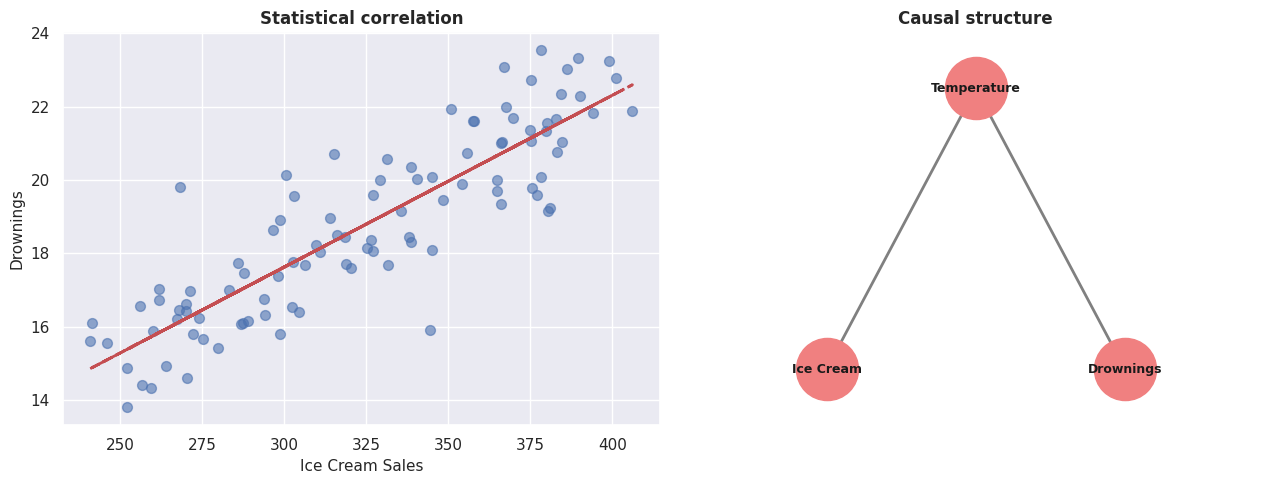

Left: Statistical view sees a correlation between ice cream sales and drownings
Right: Causal view attributes both to a common cause (temperature)


In [3]:
# Plot the correlation vs causation example.
utils.cell1_plot_correlation_vs_causation()

print(
    "Left: Statistical view sees a correlation between ice cream sales and drownings"
)
print("Right: Causal view attributes both to a common cause (temperature)")

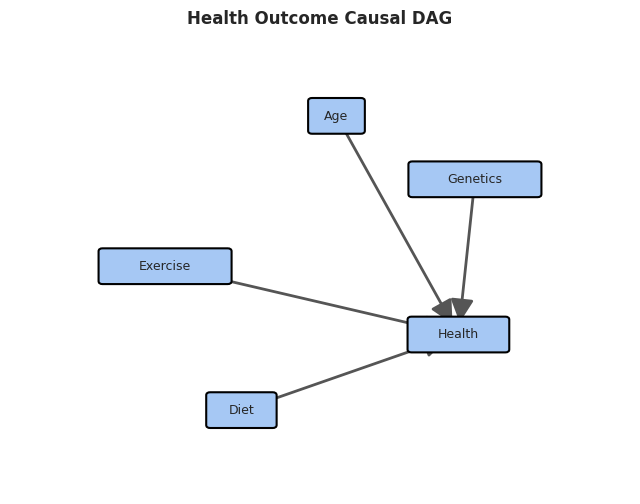

The DAG encodes the assumption that health depends on age, diet, exercise, and genetics.


In [4]:
# Create and visualize a health outcome causal DAG.
health_dag = utils.cell1_create_health_dag()

fig, ax = plt.subplots(figsize=(8, 6))
utils.cell1_plot_dag(health_dag, "Health Outcome Causal DAG", ax=ax)
plt.show()

print(
    "The DAG encodes the assumption that health depends on age, diet, exercise, and genetics."
)

# Cell 2: Building a Simple GCM by Hand

- To build a GCM, start with a simple example where we manually specify
  - The causal DAG (which variables cause which)
  - The mechanisms (functional relationships)
- Example: Temperature drives both activity and ice cream sales
  - Mechanism for activity: $\text{Activity} = 50 + 2 \times \text{Temperature} + \text{noise}$
  - Mechanism for sales: $\text{Sales} = 100 + 3 \times \text{Temperature} + 0.5 \times \text{Activity} + \text{noise}$

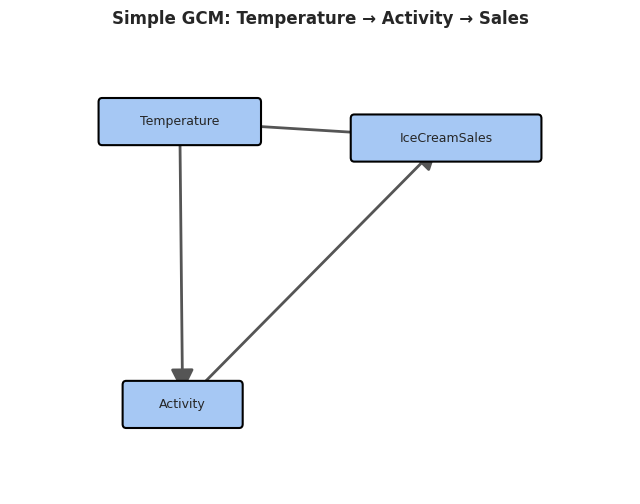

Causal edges:
  Temperature → IceCreamSales
  Temperature → Activity
  Activity → IceCreamSales


In [5]:
# Create a simple causal graph with manually defined mechanisms.
gcm, mechanisms = utils.cell2_create_simple_gcm()

fig, ax = plt.subplots(figsize=(8, 6))
utils.cell1_plot_dag(gcm, "Simple GCM: Temperature → Activity → Sales", ax=ax)
plt.show()

print("Causal edges:")
for edge in gcm.edges():
    print(f"  {edge[0]} → {edge[1]}")

In [6]:
# Generate samples from the model.
df_simple = utils.cell2_generate_samples_from_gcm(gcm, mechanisms, n_samples=200)

display(df_simple.head())
print(f"\nGenerated {len(df_simple)} samples from the GCM")

,Temperature,Activity,IceCreamSales
0,20.855025,96.340938,205.508313
1,22.199095,103.945273,229.060013
2,28.736468,100.480098,229.406016
3,28.051851,108.918549,224.530215
4,24.895492,96.537771,207.389070



Generated 200 samples from the GCM


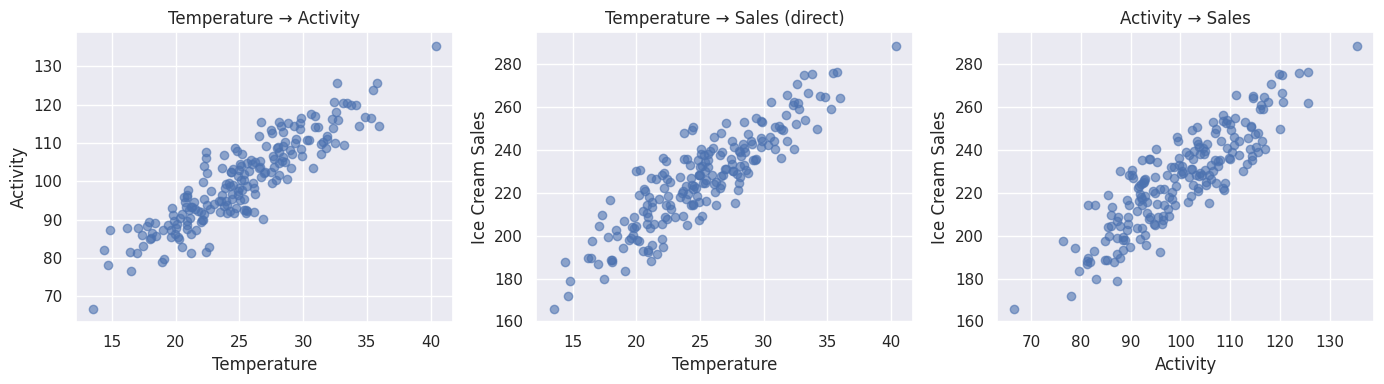

In [7]:
# Visualize relationships between variables.
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].scatter(df_simple["Temperature"], df_simple["Activity"], alpha=0.6)
axes[0].set_xlabel("Temperature")
axes[0].set_ylabel("Activity")
axes[0].set_title("Temperature → Activity")

axes[1].scatter(df_simple["Temperature"], df_simple["IceCreamSales"], alpha=0.6)
axes[1].set_xlabel("Temperature")
axes[1].set_ylabel("Ice Cream Sales")
axes[1].set_title("Temperature → Sales (direct)")

axes[2].scatter(df_simple["Activity"], df_simple["IceCreamSales"], alpha=0.6)
axes[2].set_xlabel("Activity")
axes[2].set_ylabel("Ice Cream Sales")
axes[2].set_title("Activity → Sales")

plt.tight_layout()
plt.show()

# Cell 3: Automatic Mechanism Assignment

- When working with real data, we may not know the exact mechanisms
- DoWhy can automatically assign mechanisms based on the data
  - Fit linear mechanisms by default
  - Explore nonlinear mechanisms for complex relationships
- We load the Sachs et al. protein signaling dataset with a known causal structure

In [8]:
# Load the Sachs et al. dataset with known causal structure.
df_sachs, sachs_dag = utils.cell3_load_sample_dataset("sachs")

display(df_sachs.head())
print(f"\nDataset shape: {df_sachs.shape}")
print(f"Columns: {list(df_sachs.columns)}")

,PKC,PKA,RAF,MEK,ERK,AKT
0,0.496714,0.357787,-0.548857,0.156516,0.578703,0.958533
1,-0.138264,0.560785,-0.368820,-0.514139,-0.617920,0.563047
2,0.647689,1.083051,0.326466,0.955598,0.716979,0.606431
3,1.523030,1.053802,0.785005,1.464963,0.794336,0.256920
4,-0.234153,-1.377669,-0.342109,-0.411849,-0.505542,-0.303065



Dataset shape: (200, 6)
Columns: ['PKC', 'PKA', 'RAF', 'MEK', 'ERK', 'AKT']


In [9]:
# Automatically assign mechanisms to the DAG.
mechanisms_auto = utils.cell3_assign_mechanisms_automatically(
    sachs_dag, df_sachs
)

print("Automatically assigned mechanisms:")
for node, mech in mechanisms_auto.items():
    print(f"  {node}: {mech['form'] if 'form' in mech else mech['type']}")

Automatically assigned mechanisms:
  PKC: standard normal
  PKA: standard normal
  RAF: RAF = f(PKC, PKA) + noise
  MEK: MEK = f(PKA, RAF) + noise
  ERK: ERK = f(MEK) + noise
  AKT: AKT = f(ERK, PKA) + noise


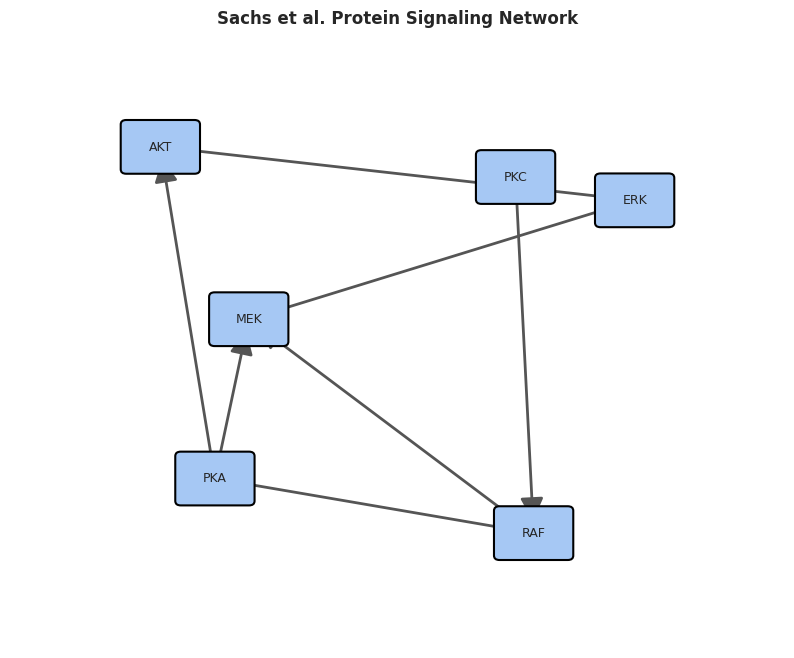

In [10]:
# Visualize the Sachs dataset causal structure.
fig, ax = plt.subplots(figsize=(10, 8))
utils.cell1_plot_dag(sachs_dag, "Sachs et al. Protein Signaling Network", ax=ax)
plt.show()

# Cell 4: Fitting an SCM to Data

- Once mechanisms are assigned, fit the model to data
- Sequential fitting: estimate parameters for each node independently
  - For each node, regress it on its parents
  - Record residuals and R² as quality metrics
- This approach is fast and interpretable for linear models

In [11]:
# Fit a simple linear SCM to the Sachs data.
fitted_params = utils.cell4_fit_scm_simple(sachs_dag, df_sachs)

print("Fitted model parameters:")
for node, params in fitted_params.items():
    if "r_squared" in params:
        print(
            f"  {node}: R² = {params['r_squared']:.3f}, Residual Std = {params['residual_std']:.3f}"
        )
    else:
        print(
            f"  {node}: Mean = {params['mean']:.3f}, Std = {params['std']:.3f}"
        )

Fitted model parameters:
  PKC: Mean = -0.041, Std = 0.931
  PKA: Mean = 0.086, Std = 0.987
  RAF: R² = 0.396, Residual Std = 0.491
  MEK: R² = 0.517, Residual Std = 0.501
  ERK: R² = 0.557, Residual Std = 0.476
  AKT: R² = 0.408, Residual Std = 0.513


# Cell 5: Generating Samples from a Fitted Model

- Once fitted, use the model to generate synthetic samples
- Forward sample through the DAG
  - Sample exogenous variables (sources)
  - For each node, apply mechanism using parent values plus noise
- Compare synthetic samples with original data to validate the fit

In [12]:
# Generate synthetic samples from the fitted model.
df_synthetic = utils.cell5_generate_synthetic_samples(
    sachs_dag, fitted_params, n_samples=200
)

display(df_synthetic.head())
print(f"\nGenerated {len(df_synthetic)} synthetic samples")

,PKC,PKA,RAF,MEK,ERK,AKT
0,0.075814,-0.947437,-0.092565,0.671629,0.240434,0.689319
1,-0.440549,0.615546,0.435116,0.444905,0.325088,0.273522
2,0.073088,1.256163,-0.343427,-0.275308,-0.516507,0.796893
3,0.465042,0.795478,-0.245747,-0.722254,-0.616900,-0.432289
4,0.004718,1.068971,-0.290722,-0.832329,-1.452981,-0.340727



Generated 200 synthetic samples


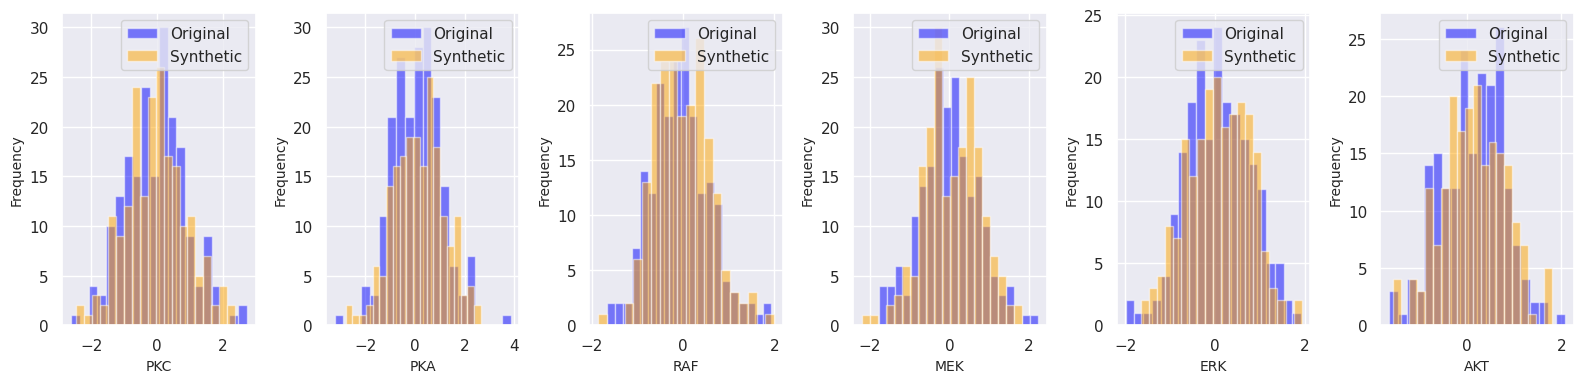

Blue: original data | Orange: synthetic data
Good alignment suggests the model captured the data distribution well.


In [13]:
# Compare original vs synthetic distributions.
utils.cell5_compare_distributions(df_sachs, df_synthetic, figsize=(16, 4))

print("Blue: original data | Orange: synthetic data")
print("Good alignment suggests the model captured the data distribution well.")

# Cell 6: Evaluating Model Quality

- Assess whether the fitted model captures the data well
- For each mechanism:
  - Compute R² (proportion of variance explained)
  - Inspect residuals for independence and normality
  - Identify variables with poor fit
- Problematic mechanisms warrant customization or more data

In [14]:
# Evaluate the quality of each fitted mechanism.
evaluation = utils.cell6_evaluate_model_quality(
    sachs_dag, fitted_params, df_sachs
)

display(evaluation)
print("\nR² values indicate how much variance each mechanism explains.")
print("Higher R² → better fit. Values < 0.5 may warrant attention.")

,Variable,Type,Mean,Std,R²,Residual Std
0,PKC,exogenous,-0.040771,0.931004,NaN,NaN
1,PKA,exogenous,0.085868,0.987004,NaN,NaN
2,RAF,linear fit,NaN,NaN,0.396246,0.491193
3,MEK,linear fit,NaN,NaN,0.516757,0.501158
4,ERK,linear fit,NaN,NaN,0.557181,0.475878
5,AKT,linear fit,NaN,NaN,0.408116,0.513274



R² values indicate how much variance each mechanism explains.
Higher R² → better fit. Values < 0.5 may warrant attention.


# Cell 7: Confidence Intervals for Causal Estimates

- Parameter estimates from finite data have uncertainty
- Use bootstrap to estimate confidence intervals
  - Resample data with replacement
  - Recompute causal quantities
  - Report percentile-based intervals
- Wider intervals indicate more uncertainty in the causal effect

In [15]:
# Estimate confidence intervals for a causal quantity via bootstrap.
treatment_var = "PKA"
outcome_var = "ERK"

point_est, ci = utils.cell7_bootstrap_confidence_intervals(
    sachs_dag, df_sachs, treatment_var, outcome_var, n_bootstrap=100
)

print(f"Effect of {treatment_var} on {outcome_var}:")
print(f"  Point estimate: {point_est:.3f}")
print(f"  95% CI: [{ci[0]:.3f}, {ci[1]:.3f}]")
print(
    "\nInterpretation: With 95% confidence, the causal effect lies in the interval."
)

Effect of PKA on ERK:
  Point estimate: 0.110
  95% CI: [-0.053, 0.292]

Interpretation: With 95% confidence, the causal effect lies in the interval.


# Cell 8: Customizing Causal Mechanism Assignment

- Automatic mechanism assignment assumes linearity
- Use custom mechanisms when domain knowledge suggests nonlinear relationships
  - Exponential growth in resource usage
  - Saturation effects (sigmoid curves)
  - Piecewise or threshold-based behaviors
- Mix automatic and custom mechanisms in the same model

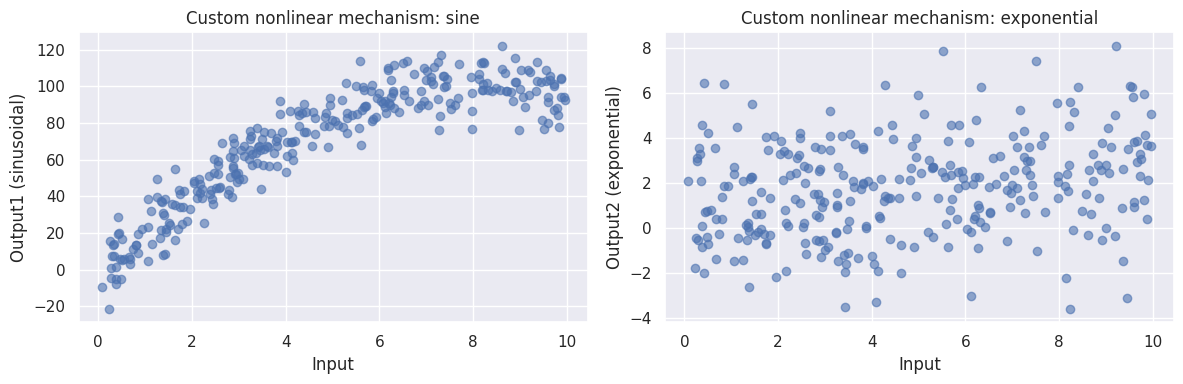

Custom mechanisms capture nonlinear relationships that linear models miss.


In [16]:
# Create a GCM with custom nonlinear mechanisms.
custom_gcm, custom_mechanisms = utils.cell8_custom_mechanism_example()

df_custom = utils.cell2_generate_samples_from_gcm(
    custom_gcm, custom_mechanisms, n_samples=300
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(df_custom["Input"], df_custom["Output1"], alpha=0.6)
axes[0].set_xlabel("Input")
axes[0].set_ylabel("Output1 (sinusoidal)")
axes[0].set_title("Custom nonlinear mechanism: sine")

axes[1].scatter(df_custom["Input"], df_custom["Output2"], alpha=0.6)
axes[1].set_xlabel("Input")
axes[1].set_ylabel("Output2 (exponential)")
axes[1].set_title("Custom nonlinear mechanism: exponential")

plt.tight_layout()
plt.show()

print(
    "Custom mechanisms capture nonlinear relationships that linear models miss."
)

# Cell 9: Root Cause Analysis Example

- Scenario: API latency increases; which system metric should we optimize?
- Build a causal model from infrastructure knowledge
  - CPU usage drives memory and network latency
  - Network latency impacts API latency
- Fit model to normal operations data
- Use counterfactual reasoning to identify highest-impact interventions

In [17]:
# Load system metrics dataset with known causal structure.
df_metrics, metrics_dag = utils.cell9_system_metrics_dataset(n_samples=300)

display(df_metrics.head())
print(f"\nDataset: {df_metrics.shape[0]} observations of system behavior")

,CpuUsage,MemoryUsage,NetworkLatency,ApiLatency
0,36.217808,41.093202,23.275382,70.070815
1,76.550001,49.706999,30.344018,93.539218
2,61.239576,59.091593,29.807982,89.388758
3,51.906094,48.741423,27.787230,85.460289
4,20.921305,26.150679,16.386036,73.128966



Dataset: 300 observations of system behavior


In [18]:
# Fit the system model.
metrics_params = utils.cell4_fit_scm_simple(metrics_dag, df_metrics)

print("System causal model fit quality:")
for node, params in metrics_params.items():
    if "r_squared" in params:
        print(f"  {node}: R² = {params['r_squared']:.3f}")

System causal model fit quality:
  MemoryUsage: R² = 0.639
  NetworkLatency: R² = 0.864
  ApiLatency: R² = 0.857


In [19]:
# Estimate impact of reducing each metric on API latency.
baseline_latency = df_metrics["ApiLatency"].mean()

# Counterfactual: reduce CPU usage by 20%
df_reduced_cpu = df_metrics.copy()
df_reduced_cpu["CpuUsage"] *= 0.8

# Estimate cascading effects
reduced_cpu_metrics = utils.cell4_fit_scm_simple(metrics_dag, df_reduced_cpu)
counterfactual_latency_cpu = df_reduced_cpu["ApiLatency"].mean()

improvement = baseline_latency - counterfactual_latency_cpu
percent_improvement = 100 * improvement / baseline_latency

print(f"Baseline API latency: {baseline_latency:.2f} ms")
print(f"Counterfactual (reduce CPU 20%): {counterfactual_latency_cpu:.2f} ms")
print(f"Improvement: {improvement:.2f} ms ({percent_improvement:.1f}%)")

Baseline API latency: 80.75 ms
Counterfactual (reduce CPU 20%): 80.75 ms
Improvement: 0.00 ms (0.0%)


# Cell 10: Medical Counterfactual Example

- Scenario: Personalized treatment recommendations
- Build a causal model of patient outcomes
  - Age and cholesterol confound treatment assignment
  - Treatment effect heterogeneity by patient characteristics
- Fit model to historical data
- Use counterfactuals to recommend treatment for new patients

In [20]:
# Load medical records dataset.
df_medical, medical_dag = utils.cell10_medical_dataset(n_samples=400)

display(df_medical.head())
print(f"\nMedical records: {df_medical.shape[0]} patients")

,Age,BloodPressure,Cholesterol,Treatment,Outcome
0,48.727006,147.672890,203.610809,0,83.180549
1,77.535715,143.470753,240.833895,1,117.747905
2,66.599697,146.799439,215.584402,1,113.483114
3,59.932924,134.877210,212.972497,0,77.453060
4,37.800932,134.581943,191.628222,0,75.051791



Medical records: 400 patients


In [21]:
# Fit the healthcare causal model.
medical_params = utils.cell4_fit_scm_simple(medical_dag, df_medical)

print("Healthcare model fit:")
for node, params in medical_params.items():
    if "r_squared" in params:
        print(f"  {node}: R² = {params['r_squared']:.3f}")

Healthcare model fit:
  BloodPressure: R² = 0.154
  Cholesterol: R² = 0.100
  Treatment: R² = 0.322
  Outcome: R² = 0.574


In [22]:
# Estimate treatment effect for a specific patient.
patient_profile = {
    "Age": 65,
    "BloodPressure": 140,
    "Cholesterol": 220,
}

# Extract relevant rows matching patient profile (approximately)
similar_patients = df_medical[
    (df_medical["Age"] >= patient_profile["Age"] - 5)
    & (df_medical["Age"] <= patient_profile["Age"] + 5)
]

outcome_with_treatment = similar_patients[similar_patients["Treatment"] == 1][
    "Outcome"
].mean()
outcome_without_treatment = similar_patients[similar_patients["Treatment"] == 0][
    "Outcome"
].mean()

treatment_effect = outcome_with_treatment - outcome_without_treatment

print(
    f"Patient: Age {patient_profile['Age']}, Cholesterol {patient_profile['Cholesterol']}"
)
print("\nEstimated outcomes:")
print(f"  With treatment: {outcome_with_treatment:.2f}")
print(f"  Without treatment: {outcome_without_treatment:.2f}")
print(f"  Treatment effect: {treatment_effect:.2f}")
print(
    f"\nRecommendation: {'Recommend treatment' if treatment_effect > 0 else 'Recommend no treatment'}"
)

Patient: Age 65, Cholesterol 220

Estimated outcomes:
  With treatment: 105.14
  Without treatment: 84.76
  Treatment effect: 20.38

Recommendation: Recommend treatment


# Cell 11: Model Limitations and When GCMs Fail

- GCMs rely on key assumptions that can be violated
  - **Causal Markov condition**: Variables conditionally independent given parents
  - **Causal sufficiency**: No hidden confounders (all causes measured)
  - **Acyclicity**: No feedback loops
  - **Mechanism autonomy**: Mechanisms don't change when other nodes intervene
- Consequences of violations:
  - Unobserved confounders → spurious correlations misattributed as causal
  - Feedback loops → DAG assumption breaks down
  - Nonlinear mechanisms fit with linear model → poor predictions

Observed correlation X ↔ Y: 0.216

This appears to show X causes Y, but actually:
  - Both X and Y are caused by an unobserved confounder
  - The correlation is spurious
  - Intervening on X would NOT change Y


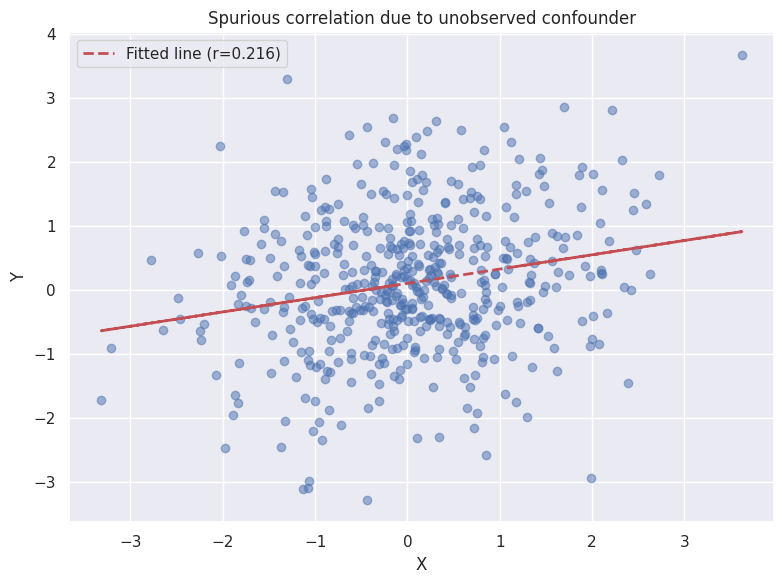

In [23]:
# Demonstrate an unobserved confounder problem.
df_confounded, _ = utils.cell11_demonstrate_unobserved_confounder()

# Naive analysis: regress Y on X
X = df_confounded["X"].values
y = df_confounded["Y"].values
naive_corr = np.corrcoef(X, y)[0, 1]

print(f"Observed correlation X ↔ Y: {naive_corr:.3f}")
print("\nThis appears to show X causes Y, but actually:")
print("  - Both X and Y are caused by an unobserved confounder")
print("  - The correlation is spurious")
print("  - Intervening on X would NOT change Y")

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df_confounded["X"], df_confounded["Y"], alpha=0.5)
z = np.polyfit(X, y, 1)
p = np.poly1d(z)
ax.plot(X, p(X), "r--", lw=2, label=f"Fitted line (r={naive_corr:.3f})")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("Spurious correlation due to unobserved confounder")
ax.legend()
plt.tight_layout()
plt.show()